# Post-stimulus (evoked) noise correlations vs LDA 1
Window 0–0.2 s. Stimulus- and choice-driven signal is removed by z-scoring each neuron within (condition × choice) groups, so r_SC reflects trial-to-trial **noise** only. Within-region pairs; per-pair rates saved; rate-corrected; correlated with LDA 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor']='white' 

In [51]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_dir = prefix + 'neural/'

WINDOW = (0, 0.25)           # post-stimulus window (s) — extended to 400 ms
REGION_FILTER = 'drop_root'   # None | 'drop_root' | list of acronyms
MIN_RATE = 0.5                # Hz
MIN_TRIALS = 50               # usable trials per session
MIN_NEURONS = 5
MIN_GROUP_TRIALS = 5          # min trials per (condition x choice) group to z-score within
SEED = 0

def area_mask(a):
    if REGION_FILTER is None: return np.ones(len(a), dtype=bool)
    if REGION_FILTER == 'drop_root': return (a != 'root').values
    return a.isin(REGION_FILTER).values

lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
trials_df = pd.read_parquet(trials_path)
# per-session trial -> choice  (stimulus condition comes from the firing files)
choice_by_session = {s: g.set_index('trial_id')['choice']
                     for s, g in trials_df.groupby('session')}

def partial_corr(x, y, z):
    x, y, z = map(lambda v: np.asarray(v, float), (x, y, z))
    Z = np.c_[np.ones_like(z), z]
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return pearsonr(rx, ry)
print("params set; window =", WINDOW)

params set; window = (0, 0.25)


## Load single-trial evoked rates

In [52]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
wcols = [c for c, m in zip(tcols, (tsec >= WINDOW[0]) & (tsec <= WINDOW[1])) if m]
print(f"Evoked window {WINDOW}: {len(wcols)} of {len(tcols)} bins")

sess_pivots = defaultdict(list)
sess_cond = {}
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[area_mask(d['area'])]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy()
        d['rate'] = np.nanmean(d[wcols].values, axis=1)
        d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        sess_pivots[session].append((d.pivot_table(index='trial_id', columns='nuid', values='rate'),
                                     d.groupby('nuid')['area'].first()))
        if session not in sess_cond:
            sess_cond[session] = d.drop_duplicates('trial_id').set_index('trial_id')['condition']
        if (i+1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")
print(f"Sessions: {len(sess_pivots)}")

Evoked window (0, 0.25): 15 of 90 bins
  100/380 files...
  200/380 files...
  300/380 files...
Sessions: 244


## r_SC after removing stimulus×choice signal

In [53]:
pair_session, pair_area, pair_r, pair_geo = [], [], [], []
info = []
for session, parts in sess_pivots.items():
    X = pd.concat([p for p, _ in parts], axis=1)
    areas = pd.concat([a for _, a in parts]); areas = areas[~areas.index.duplicated()]

    # grouping label per trial: stimulus condition x choice
    cond = sess_cond[session].reindex(X.index).astype(str)
    choice = choice_by_session.get(session, pd.Series(dtype=object)).reindex(X.index).astype(str)
    grp = (cond + '|' + choice)
    grp = grp[~(cond.eq('nan') | choice.eq('nan'))]               # drop trials missing cond/choice
    X = X.loc[grp.index]

    # keep only groups with enough trials to z-score within
    vc = grp.value_counts()
    good = grp.isin(vc[vc >= MIN_GROUP_TRIALS].index)
    X, grp = X.loc[good[good].index], grp.loc[good[good].index]
    if X.shape[0] < MIN_TRIALS: continue

    rates = X.mean(axis=0)                                        # raw evoked rate (for geo + QC)
    keep = (rates >= MIN_RATE) & (X.std(axis=0) > 0)
    X = X.loc[:, keep.values]; areas2 = areas.reindex(X.columns)
    if X.shape[1] < MIN_NEURONS: continue

    # z-score each neuron WITHIN each (condition x choice) group -> residual = noise
    gm = X.groupby(grp).transform('mean')
    gs = X.groupby(grp).transform('std')
    Zr = (X - gm) / gs
    Zr = Zr.replace([np.inf, -np.inf], np.nan)
    okn = Zr.notna().all(axis=0)                                  # drop neurons NaN in any group
    Zr = Zr.loc[:, okn.values]; areas2 = areas2.reindex(Zr.columns)
    raw_rate = rates.reindex(Zr.columns)
    if Zr.shape[1] < MIN_NEURONS: continue

    info.append(dict(session=session, n_neurons=Zr.shape[1], n_trials=Zr.shape[0],
                     mean_rate=float(raw_rate.mean())))
    for region, neurons in areas2.groupby(areas2):
        cols = neurons.index
        if len(cols) < 2: continue
        C = np.corrcoef(Zr[cols].values, rowvar=False)
        rv = raw_rate[cols].values
        iu, ju = np.triu_indices(len(cols), k=1)
        pair_session.append(np.repeat(session, len(iu)))
        pair_area.append(np.repeat(region, len(iu)))
        pair_r.append(C[iu, ju]); pair_geo.append(np.sqrt(rv[iu] * rv[ju]))

pairs = pd.DataFrame({'session': np.concatenate(pair_session), 'area': np.concatenate(pair_area),
                      'rSC': np.concatenate(pair_r), 'geo_rate': np.concatenate(pair_geo)}).dropna(subset=['rSC'])
info_df = pd.DataFrame(info)
print(f"Pairs: {len(pairs):,} | sessions: {pairs['session'].nunique()} | mean evoked r_SC = {pairs['rSC'].mean():.4f}")

Pairs: 537,758 | sessions: 241 | mean evoked r_SC = 0.0476


In [54]:
m = pairs['geo_rate'] > 0
b = np.polyfit(np.log(pairs.loc[m, 'geo_rate']), pairs.loc[m, 'rSC'], 1)
pairs['rSC_corrected'] = pairs['rSC'] - np.polyval(b, np.log(pairs['geo_rate'].clip(lower=1e-3))) + pairs['rSC'].mean()

session_df = (pairs.groupby('session').agg(mean_rSC=('rSC','mean'),
              rSC_rate_corrected=('rSC_corrected','mean'), n_pairs=('rSC','size'),
              geo_rate=('geo_rate','mean')).reset_index().merge(info_df, on='session', how='left'))
pairs.to_parquet(out_dir + 'noise_corr_pairs_evoked.parquet')
session_df.to_parquet(out_dir + 'noise_corr_session_evoked.parquet')
print(f"rate-correction slope: {b[0]:+.4f}; saved {len(pairs):,} pairs, {len(session_df)} sessions")

rate-correction slope: +0.0088; saved 537,758 pairs, 241 sessions


## Evoked r_SC vs LDA 1 (all regions + per-region scan)

In [55]:
nc = session_df.merge(lda[['session','lda_1']], on='session').dropna(subset=['mean_rSC','lda_1'])
for col,label in [('mean_rSC','raw'),('rSC_rate_corrected','rate-corr')]:
    r,p = pearsonr(nc[col], nc['lda_1']); rho,pp = spearmanr(nc[col], nc['lda_1'])
    pr,ppr = partial_corr(nc[col], nc['lda_1'], nc['mean_rate'])
    print(f"all-region {label}: pearson r={r:+.3f} p={p:.3f} | spearman rho={rho:+.3f} p={pp:.3f} | partial(rate) r={pr:+.3f} p={ppr:.3f}")

# region scan
_reg = pairs.groupby(['session','area'],as_index=False).agg(rSC=('rSC','mean'),geo_rate=('geo_rate','mean'),n_pairs=('rSC','size'))
_reg = _reg.merge(lda[['session','lda_1']], on='session')
base = _reg[_reg['n_pairs']>=10].dropna(subset=['rSC','lda_1'])
rows=[]
for region,g in base.groupby('area'):
    if g['session'].nunique()<15: continue
    n=len(g); r,p=pearsonr(g['rSC'],g['lda_1']); rho,pp=spearmanr(g['rSC'],g['lda_1'])
    pr,ppr=partial_corr(g['rSC'],g['lda_1'],g['geo_rate'])
    zse=1/np.sqrt(n-3); lo,hi=np.tanh(np.arctanh(r)-1.96*zse),np.tanh(np.arctanh(r)+1.96*zse)
    rows.append(dict(region=region,n=n,pearson_r=r,p=p,ci_lo=lo,ci_hi=hi,spearman_p=pp,partial_r=pr,p_partial=ppr))
scan=pd.DataFrame(rows).sort_values('n',ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', lambda v:f'{v:.3f}')
print("\n", scan.to_string(index=False))
print(f"\nRegions tested: {len(scan)} (Bonferroni alpha={0.05/max(1,len(scan)):.4f})")

all-region raw: pearson r=-0.103 p=0.112 | spearman rho=-0.140 p=0.030 | partial(rate) r=-0.094 p=0.147
all-region rate-corr: pearson r=-0.105 p=0.105 | spearman rho=-0.143 p=0.027 | partial(rate) r=-0.088 p=0.171

 region  n  pearson_r     p  ci_lo  ci_hi  spearman_p  partial_r  p_partial
   CA1 44     -0.080 0.607 -0.368  0.223       0.786     -0.119      0.442
   MRN 40      0.024 0.883 -0.290  0.333       0.858      0.042      0.797
    CP 39      0.159 0.334 -0.165  0.452       0.458      0.146      0.375
    LP 32     -0.114 0.535 -0.445  0.245       0.855     -0.102      0.578
    DG 29      0.048 0.804 -0.324  0.407       0.431      0.049      0.800
   CA3 24      0.043 0.843 -0.367  0.439       0.843     -0.059      0.783
    PO 23      0.052 0.812 -0.368  0.455       0.359      0.052      0.815
   APN 22     -0.043 0.851 -0.456  0.386       0.852     -0.041      0.856
   MOs 20      0.144 0.545 -0.319  0.551       0.935      0.153      0.520
   MOp 20     -0.160 0.499 -0.563 

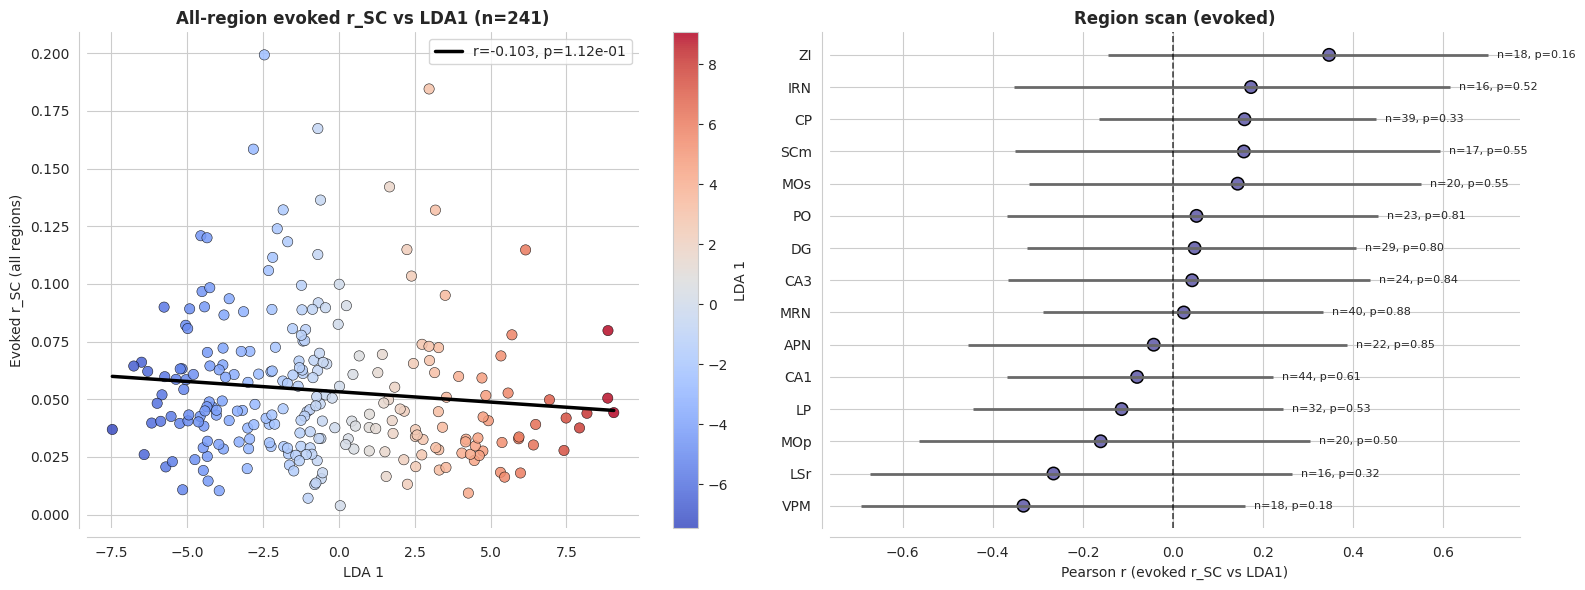

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# all-region scatter
x=nc['lda_1'].values; y=nc['mean_rSC'].values; r,p=pearsonr(y,x)
sc=axes[0].scatter(x,y,c=x,cmap='coolwarm',s=55,alpha=0.85,edgecolors='black',linewidth=0.4)
axes[0].plot(np.linspace(x.min(),x.max(),100), np.polyval(np.polyfit(x,y,1),np.linspace(x.min(),x.max(),100)),'k-',lw=2.5,label=f'r={r:.3f}, p={p:.2e}')
fig.colorbar(sc,ax=axes[0]).set_label('LDA 1')
axes[0].set_xlabel('LDA 1'); axes[0].set_ylabel('Evoked r_SC (all regions)')
axes[0].set_title(f'All-region evoked r_SC vs LDA1 (n={len(nc)})',fontweight='bold'); axes[0].legend()
# region forest
d=scan.sort_values('pearson_r').reset_index(drop=True); yy=np.arange(len(d))
colors=['#d95f02' if pp<0.05 else '#7570b3' for pp in d['p']]
axes[1].hlines(yy,d['ci_lo'],d['ci_hi'],color='dimgray',lw=2)
axes[1].scatter(d['pearson_r'],yy,c=colors,s=80,edgecolors='black',lw=1.1)
axes[1].axvline(0,color='black',ls='--',lw=1.2,alpha=0.7)
for i,row in d.iterrows(): axes[1].text(row['ci_hi']+0.02,i,f"n={int(row['n'])}, p={row['p']:.2f}",va='center',fontsize=8)
axes[1].set_yticks(yy); axes[1].set_yticklabels(d['region'])
axes[1].set_xlabel('Pearson r (evoked r_SC vs LDA1)'); axes[1].set_title('Region scan (evoked)',fontweight='bold')
for ax in axes: sns.despine(ax=ax,offset=6)
plt.tight_layout(); plt.show()